### [ 과제: 타이타닉 생존자 예측 ] <hr>

In [2]:

## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
import seaborn as sns
sys.path.append(r"C:\KDT14\7_CV")
import importlib
import cv_utils
importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [5]:
## 데이터 불러오기
df= pd.read_csv('../Data/Numbers/titanic_train.csv')

df.head(5)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [7]:
## 책에서는 이렇게 되어 있는데 이건 pandas= 3.0 이전 버전

# df['Age'].fillna(df['Age'].mean(),inplace=True)
# df['Cabin'].fillna('N',inplace=True)
# df['Embarked'].fillna('N',inplace=True)
# print('데이터 세트 Null 값 갯수 ', df.isnull().sum().sum())


# 이렇게 사용할 것
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Cabin'] = df['Cabin'].fillna('N')
df['Embarked'] = df['Embarked'].fillna('N')


In [8]:
print(' Sex 값 분포 :\n',df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n',df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n',df['Embarked'].value_counts())

 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [ ]:
df['Cabin'] = df['Cabin'].str[:1]
print(df['Cabin'].head(3)) # 등급을 뜻함

0    N
1    C
2    N
Name: Cabin, dtype: object


In [11]:
df.groupby(['Sex','Survived'])['Survived'].count()
# 여자는 74.2% 생존, 남자는 18.8% 생존

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

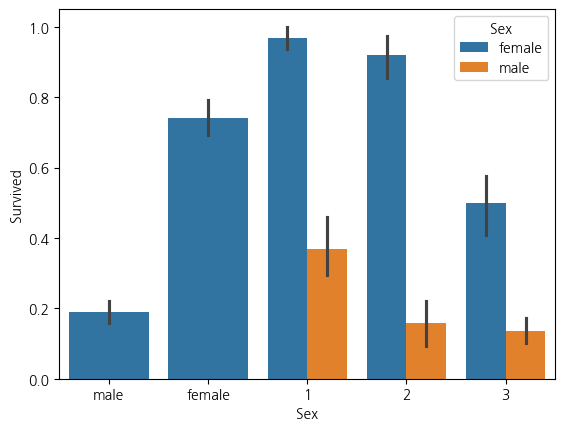

In [13]:
sns.barplot(x='Sex', y = 'Survived', data= df)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data= df)

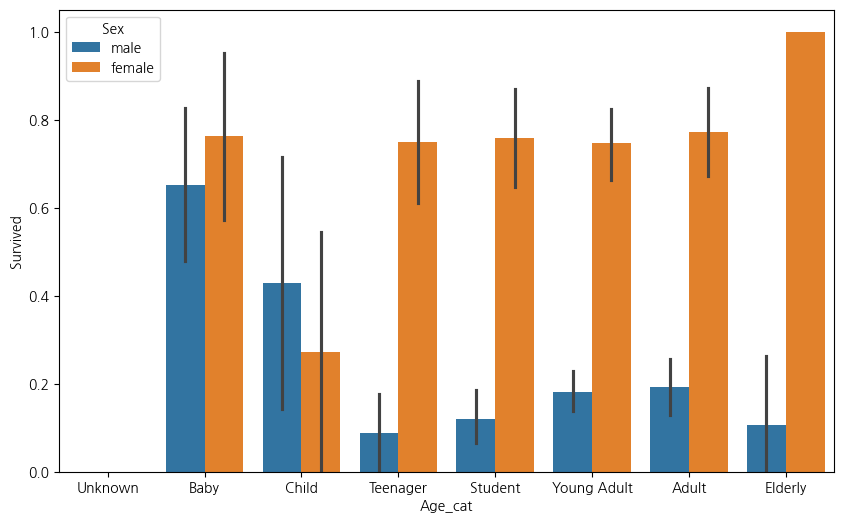

In [14]:
# 입력 age에 따라 구분값을 반환하는 함수 설정. DataFrame의 apply lambda식에 사용. 
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    
    return cat

# 막대그래프의 크기 figure를 더 크게 설정 
plt.figure(figsize=(10,6))

#X축의 값을 순차적으로 표시하기 위한 설정 
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정. 
# get_category(X)는 입력값으로 'Age' 컬럼값을 받아서 해당하는 cat 반환
df['Age_cat'] = df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y = 'Survived', hue='Sex', data=df, order=group_names)
df.drop('Age_cat', axis=1, inplace=True)

In [17]:
from sklearn import preprocessing
## 'Cabin', 'Sex', 'Embarked' 이 숫자형으로 속성이 바뀜

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = preprocessing.LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])
        
    return dataDF

df = encode_features(df)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


- **함수 생성해서 다시 데이터 가공하기**

In [22]:
from sklearn.preprocessing import LabelEncoder

## 데이터 전처리하는 함수 생성



# Null 처리 함수 //// 이게 업뎃떄문에 안 돼서 바꿔씀
# def fillna(df):
#     df['Age'].fillna(df['Age'].mean(), inplace=True)
#     df['Cabin'].fillna('N', inplace=True)
#     df['Embarked'].fillna('N', inplace=True)
#     df['Fare'].fillna(0, inplace=True)
#     return df

def fillna(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)

    return df



# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [23]:
titanic_df = pd.read_csv('../Data/Numbers/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived',axis=1)

X_titanic_df = transform_features(X_titanic_df)

#### [ ML 알고리즘 ] <hr>
- 의사결정 트리: DecisionTreeClassifier 사용
- 랜덤포레스트: RandomForestClassifier 사용
- 로지스틱 회귀: LogisticRegression 사용

In [24]:
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, \
                                                  test_size=0.2, random_state=11)

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 결정트리, Random Forest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state=11) # 이때 11은 그냥 같은 결과 출력하려고 설정한 숫자
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear') # 로지스틱 회귀의 최적화 알고리즘을 liblinear로 설정한 것


# !! 일반적으로 작은 데이터셋에서의 이진분류는 liblinear가 성능이 약간 더 좋음


# DecisionTreeClassifier 학습/예측/평가
dt_clf.fit(X_train , y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습/예측/평가
rf_clf.fit(X_train , y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 학습/예측/평가
lr_clf.fit(X_train , y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


LogisticRegression 정확도: 0.8659---> 로지스틱이 성능이 제일 좋지만 데이터양이 충분하지 않아 절대적인 수치는 아님

In [28]:


def exec_kfold(clf, folds=5):
    """
    전달받은 분류 모델(clf)을 KFold 방식으로 교차 검증하는 함수

    clf   : 교차 검증할 분류 모델
    folds : 데이터를 나눌 폴드 개수, 기본값은 5
    """

    # 전체 데이터를 5개 구간으로 나눔
    kfold = KFold(n_splits=folds)

    # 각 폴드에서 계산한 정확도를 저장할 리스트
    scores = []


    # kfold.split(X_titanic_df)
    # → 각 교차 검증에 사용할 학습 데이터 인덱스와 검증 데이터 인덱스를 반환
    #
    # enumerate()
    # → 현재 몇 번째 교차 검증인지 iter_count에 저장
    for iter_count, (train_index, test_index) in enumerate( kfold.split( X_titanic_df)):

        # train_index
        # → 현재 회차에서 학습에 사용할 데이터의 행 번호
        #
        # test_index
        # → 현재 회차에서 검증에 사용할 데이터의 행 번호

        # 입력 데이터 X를 학습용과 검증용으로 분리
        # DataFrame의 values를 이용해 NumPy 배열로 변환한 뒤
        # train_index와 test_index에 해당하는 행을 가져옴
        X_train = X_titanic_df.values[train_index]
        X_test = X_titanic_df.values[test_index]

        # 정답 데이터 y도 동일한 인덱스를 사용하여 분리
        y_train = y_titanic_df.values[train_index]
        y_test = y_titanic_df.values[test_index]

        clf.fit(X_train, y_train)

        # 현재 폴드의 검증 데이터로 생존 여부 예측
        predictions = clf.predict(X_test)

        # 실제 정답 y_test와 모델 예측값 predictions를 비교하여 정확도 계산
        accuracy = accuracy_score(y_test, predictions)

        # 현재 폴드의 정확도를 scores 리스트에 저장
        scores.append(accuracy)

        # 현재 교차 검증 회차의 정확도 출력
        print(
            "교차 검증 {0} 정확도: {1:.4f}".format(
                iter_count,
                accuracy
            )
        )


    # 모든 폴드에서 나온 정확도의 평균 계산
    mean_score = np.mean(scores)

    # 평균 정확도 출력
    print("평균 정확도: {0:.4f}".format(mean_score))

exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


cross_val_score() 활용

In [29]:
scores= cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)

for iter_count, accuracy in enumerate(scores):
    print(" 교차검증 {0} 정확도: {1:.4f}". format(iter_count, accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

 교차검증 0 정확도: 0.7430
 교차검증 1 정확도: 0.7753
 교차검증 2 정확도: 0.7921
 교차검증 3 정확도: 0.7865
 교차검증 4 정확도: 0.8427
평균 정확도: 0.7879


↑ 왜 두 정확도가 다르냐면
- KFold는 정답인 Survived의 비율을 고려하지 않고, 단순히 데이터를 5구간으로 나눴고
- cross_val_score()는 StratifiedKFOLD 를 이용해 세트 분할 했기 때문

In [30]:
## 그리드 CV 사용 


parameters = {'max_depth':[2,3,5,10],
             'min_samples_split':[2,3,5], 'min_samples_leaf':[1,5,8]}

grid_dclf = GridSearchCV(dt_clf , param_grid=parameters , scoring='accuracy' , cv=5)
grid_dclf.fit(X_train , y_train)

print('GridSearchCV 최적 하이퍼 파라미터 :',grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

# GridSearchCV의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가 수행. 
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test , dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715
